In [4]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [5]:
# 读取文件并提取数据
def extract_reward_data(filename):
    """
    从文件中提取step和reward数据
    """
    steps = []
    rewards = []
    grads = []
    
    # 使用正则表达式匹配需要的行
    pattern = r'\[Step (\d+)/\d+\] reward=([0-9.]+), grad=([0-9.]+)'
    
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            match = re.search(pattern, line)
            if match:
                step = int(match.group(1))
                reward = float(match.group(2))
                grad = float(match.group(3))
                
                steps.append(step)
                rewards.append(reward)
                grads.append(grad)
    
    return steps, rewards, grads

def plot_reward_curve(steps, rewards, grads=None):
    """
    绘制reward随step变化的曲线
    """
    # 创建图形，设置中文字体
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号
    
    if grads:
        # 如果有grad数据，创建两个子图
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        
        # 绘制reward曲线
        ax1.plot(steps, rewards, 'b-o', markersize=4, linewidth=1.5, label='Reward')
        ax1.set_xlabel('Step')
        ax1.set_ylabel('Reward')
        ax1.set_title('Reward with step')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # 绘制grad曲线
        ax2.plot(steps, grads, 'r-s', markersize=4, linewidth=1.5, label='Grad')
        ax2.set_xlabel('Step')
        ax2.set_ylabel('Grad')
        ax2.set_title('Grad with step')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
    else:
        # 只绘制reward曲线
        plt.figure(figsize=(10, 6))
        plt.plot(steps, rewards, 'b-o', markersize=4, linewidth=1.5, label='Reward')
        plt.xlabel('Step')
        plt.ylabel('Reward')
        plt.title('Reward with step')
        plt.grid(True, alpha=0.3)
        plt.legend()
    
    plt.tight_layout()
    plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

找到 11 条数据记录
Step 范围: 1 - 11
Reward 范围: 0.5391 - 0.6641
平均 Reward: 0.6120
Reward 标准差: 0.0376

Grad 范围: 3.1820 - 4.3449
平均 Grad: 3.6253


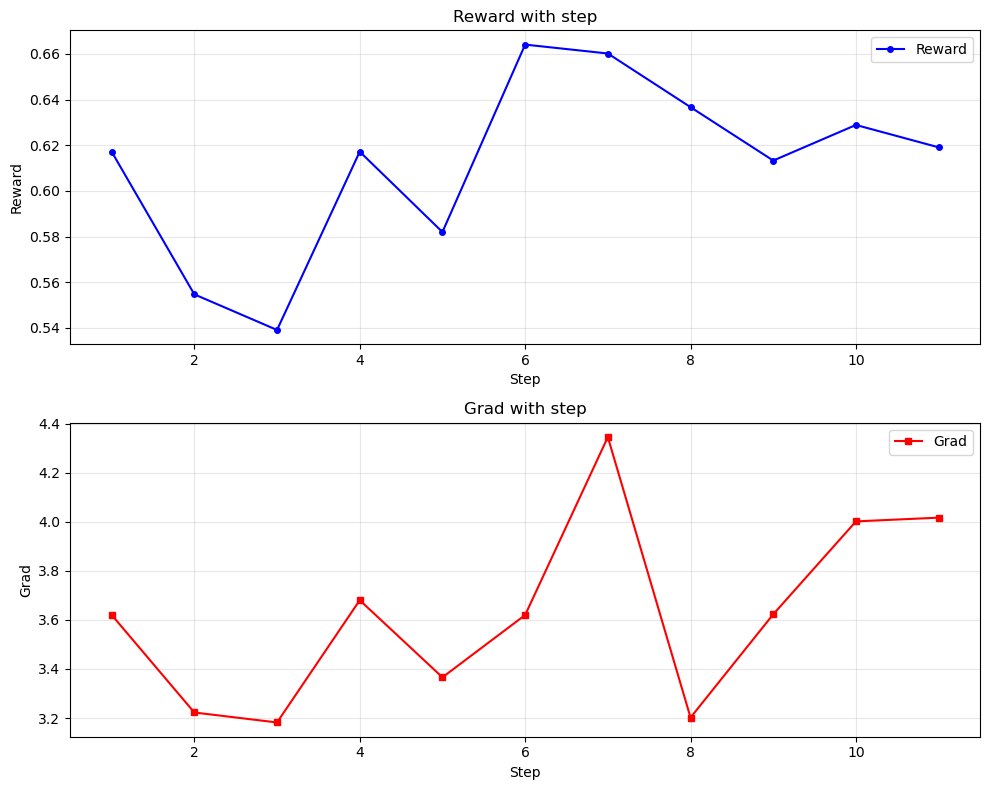

In [6]:
# 指定输入文件名（请修改为你的实际文件名）
input_file = 'logs/checkpoints_math500_num_generation8_t0.3.log'  # 请替换为实际文件名


# 提取数据
steps, rewards, grads = extract_reward_data(input_file)

# 打印统计信息
print(f"找到 {len(steps)} 条数据记录")
print(f"Step 范围: {min(steps)} - {max(steps)}")
print(f"Reward 范围: {min(rewards):.4f} - {max(rewards):.4f}")
print(f"平均 Reward: {np.mean(rewards):.4f}")
print(f"Reward 标准差: {np.std(rewards):.4f}")

if grads:
    print(f"\nGrad 范围: {min(grads):.4f} - {max(grads):.4f}")
    print(f"平均 Grad: {np.mean(grads):.4f}")

# 绘制曲线
plot_reward_curve(steps, rewards, grads)

对比不同解码方式的rollout

In [7]:
import re
import numpy as np
from pathlib import Path
from collections import Counter

def parse_diversity_line(line):
    """
    解析单行diversity数据，提取完整信息
    示例: diversity| distinct_answer_num: 6 | all_answer_num: 8 | distinct_answer_ratio: 0.75 | best_answer_ratio: 0.38 | correct_answer_number: 1 | best_is_correct: 0 | extracted_answers: ['0', '33.33', '22', '33.33', '33.33', '36.25', '24', '42'] | majority_answer: 33.33 | ground_truth_answer: 22
    """
    # 解析基础指标
    pattern = r'diversity\|\s*distinct_answer_num:\s*(\d+).*?all_answer_num:\s*(\d+).*?best_answer_ratio:\s*([0-9.]+).*?correct_answer_number:\s*(\d+).*?best_is_correct:\s*(\d+)'
    match = re.search(pattern, line)
    
    if not match:
        return None
    
    # 提取答案列表
    answers_pattern = r'extracted_answers:\s*\[(.*?)\]'
    answers_match = re.search(answers_pattern, line)
    extracted_answers = []
    if answers_match:
        # 解析答案列表字符串
        answers_str = answers_match.group(1)
        # 处理引号内的内容
        extracted_answers = re.findall(r"'([^']*)'", answers_str)
    
    # 提取多数投票答案
    majority_pattern = r'majority_answer:\s*([^\s|]+)'
    majority_match = re.search(majority_pattern, line)
    majority_answer = majority_match.group(1) if majority_match else None
    
    # 提取真实答案
    truth_pattern = r'ground_truth_answer:\s*([^\s|]+)'
    truth_match = re.search(truth_pattern, line)
    ground_truth = truth_match.group(1) if truth_match else None
    
    return {
        'distinct_answer_num': int(match.group(1)),
        'all_answer_num': int(match.group(2)),
        'best_answer_ratio': float(match.group(3)),
        'correct_answer_number': int(match.group(4)),
        'best_is_correct': int(match.group(5)),
        'extracted_answers': extracted_answers,
        'majority_answer': majority_answer,
        'ground_truth': ground_truth
    }

def calculate_reward_metrics(answers, majority_answer, ground_truth):
    """
    计算reward accuracy和相关指标
    
    Args:
        answers: 所有rollout的答案列表
        majority_answer: 多数投票答案
        ground_truth: 真实答案
    
    Returns:
        dict: 包含各项指标
    """
    n = len(answers)
    if n == 0 or majority_answer is None or ground_truth is None:
        return {
            'reward_accuracy': 0,
            'true_positive_ratio': 0,
            'true_negative_ratio': 0,
            'false_positive_ratio': 0,
            'false_negative_ratio': 0
        }
    
    # 为每个rollout计算估计奖励和真实奖励
    tp = fp = tn = fn = 0
    
    for ans in answers:
        est_reward = 1 if ans == majority_answer else 0  # 估计奖励：是否匹配多数投票
        true_reward = 1 if ans == ground_truth else 0     # 真实奖励：是否真实正确
        
        if est_reward == 1 and true_reward == 1:
            tp += 1  # True Positive: 估计正确且真实正确
        elif est_reward == 1 and true_reward == 0:
            fp += 1  # False Positive: 估计正确但真实错误
        elif est_reward == 0 and true_reward == 1:
            fn += 1  # False Negative: 估计错误但真实正确
        elif est_reward == 0 and true_reward == 0:
            tn += 1  # True Negative: 估计错误且真实错误
    
    # 计算各项指标
    total = tp + fp + tn + fn
    
    # Reward Accuracy: 估计奖励与真实奖励一致的比例
    reward_accuracy = (tp + tn) / total if total > 0 else 0
    
    # True Positive Ratio: TP / (TP + FN)
    true_positive_ratio = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # True Negative Ratio: TN / (TN + FP)
    true_negative_ratio = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # False Positive Ratio: FP / (FP + TN)
    false_positive_ratio = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # False Negative Ratio: FN / (FN + TP)
    false_negative_ratio = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    return {
        'reward_accuracy': reward_accuracy,
        'true_positive_ratio': true_positive_ratio,
        'true_negative_ratio': true_negative_ratio,
        'false_positive_ratio': false_positive_ratio,
        'false_negative_ratio': false_negative_ratio,
        # 也返回原始计数以便调试
        'tp_count': tp,
        'fp_count': fp,
        'tn_count': tn,
        'fn_count': fn
    }

def calculate_metrics(data_list):
    """
    从数据列表中计算各项指标
    过滤掉所有rollout相同的样本（无法产生梯度）
    """
    if not data_list:
        return {
            'avg_distinct_num': 0,
            'avg_best_ratio': 0,
            'avg_correct_num': 0,
            'avg_accuracy': 0,
            'voting_accuracy': 0,
            'consistency': 0,
            'num_samples': 0,
            'good_reward_ratio': 0,
            'zero_reward_ratio': 0,
            'bad_reward_ratio': 0,
            'effective_sample_ratio': 0,  # 有效样本比例（distinct_num > 1）
            'effective_reward_accuracy': 0,  # 有效样本中的reward accuracy
            'effective_tp_ratio': 0,
            'effective_fp_ratio': 0,
            'effective_tn_ratio': 0,
            'effective_fn_ratio': 0,
            'overall_reward_accuracy': 0,  # 所有样本（包括无效）的reward accuracy（供参考）
        }
    
    n_samples = len(data_list)
    all_answer_num = data_list[0]['all_answer_num']
    
    # 原有的指标计算
    avg_distinct_num = np.mean([d['distinct_answer_num'] for d in data_list])
    avg_best_ratio = np.mean([d['best_answer_ratio'] for d in data_list])
    avg_correct_num = np.mean([d['correct_answer_number'] for d in data_list])
    avg_accuracy = avg_correct_num / all_answer_num
    voting_accuracy = np.mean([d['best_is_correct'] for d in data_list])
    
    # 样本类型比例
    good_reward_count = zero_reward_count = bad_reward_count = 0
    for d in data_list:
        if d['distinct_answer_num'] == 1:
            zero_reward_count += 1
        elif d['best_is_correct'] == 1:
            good_reward_count += 1
        else:
            bad_reward_count += 1
    
    # ========== 有效样本过滤 ==========
    # 有效样本：distinct_answer_num > 1（有多样性，能产生梯度）
    effective_samples = [d for d in data_list if d['distinct_answer_num'] > 1]
    effective_sample_ratio = len(effective_samples) / n_samples if n_samples > 0 else 0
    
    # 在所有样本上计算overall reward accuracy（包括无效样本）
    total_tp_all = total_fp_all = total_tn_all = total_fn_all = 0
    
    # 在有效样本上计算effective reward metrics
    total_tp_eff = total_fp_eff = total_tn_eff = total_fn_eff = 0
    
    for d in data_list:
        if 'extracted_answers' not in d or not d['majority_answer'] or not d['ground_truth']:
            continue
            
        answers = d['extracted_answers']
        majority = d['majority_answer']
        truth = d['ground_truth']
        is_effective = d['distinct_answer_num'] > 1
        
        for ans in answers:
            est_reward = 1 if ans == majority else 0
            true_reward = 1 if ans == truth else 0
            
            # 统计所有样本
            if est_reward == 1 and true_reward == 1:
                total_tp_all += 1
            elif est_reward == 1 and true_reward == 0:
                total_fp_all += 1
            elif est_reward == 0 and true_reward == 0:
                total_tn_all += 1
            elif est_reward == 0 and true_reward == 1:
                total_fn_all += 1
            
            # 只统计有效样本
            if is_effective:
                if est_reward == 1 and true_reward == 1:
                    total_tp_eff += 1
                elif est_reward == 1 and true_reward == 0:
                    total_fp_eff += 1
                elif est_reward == 0 and true_reward == 0:
                    total_tn_eff += 1
                elif est_reward == 0 and true_reward == 1:
                    total_fn_eff += 1
    
    # 计算overall指标（所有样本）
    total_rollouts_all = total_tp_all + total_fp_all + total_tn_all + total_fn_all
    if total_rollouts_all > 0:
        overall_reward_accuracy = (total_tp_all + total_tn_all) / total_rollouts_all
        overall_tp_ratio = total_tp_all / total_rollouts_all
        overall_fp_ratio = total_fp_all / total_rollouts_all
        overall_tn_ratio = total_tn_all / total_rollouts_all
        overall_fn_ratio = total_fn_all / total_rollouts_all
    else:
        overall_reward_accuracy = overall_tp_ratio = overall_fp_ratio = overall_tn_ratio = overall_fn_ratio = 0
    
    # 计算effective指标（只有有效样本）
    total_rollouts_eff = total_tp_eff + total_fp_eff + total_tn_eff + total_fn_eff
    if total_rollouts_eff > 0:
        effective_reward_accuracy = (total_tp_eff + total_tn_eff) / total_rollouts_eff
        effective_tp_ratio = total_tp_eff / total_rollouts_eff
        effective_fp_ratio = total_fp_eff / total_rollouts_eff
        effective_tn_ratio = total_tn_eff / total_rollouts_eff
        effective_fn_ratio = total_fn_eff / total_rollouts_eff
    else:
        effective_reward_accuracy = effective_tp_ratio = effective_fp_ratio = effective_tn_ratio = effective_fn_ratio = 0
    
    # 验证有效样本的比例之和为1
    if total_rollouts_eff > 0:
        assert abs(effective_tp_ratio + effective_fp_ratio + effective_tn_ratio + effective_fn_ratio - 1.0) < 1e-10, \
               f"有效样本比例之和应为1，实际为{effective_tp_ratio + effective_fp_ratio + effective_tn_ratio + effective_fn_ratio}"
    
    return {
        # 原有指标
        'avg_distinct_num': avg_distinct_num,
        'avg_best_ratio': avg_best_ratio,
        'avg_correct_num': avg_correct_num,
        'avg_accuracy': avg_accuracy,
        'voting_accuracy': voting_accuracy,
        'consistency': avg_best_ratio,
        'num_samples': n_samples,
        'good_reward_ratio': good_reward_count / n_samples,
        'zero_reward_ratio': zero_reward_count / n_samples,
        'bad_reward_ratio': bad_reward_count / n_samples,
        
        # 新增：有效样本比例
        'effective_sample_ratio': effective_sample_ratio,
        
        # 有效样本上的reward metrics
        'effective_reward_accuracy': effective_reward_accuracy,
        'effective_tp_ratio': effective_tp_ratio,
        'effective_fp_ratio': effective_fp_ratio,
        'effective_tn_ratio': effective_tn_ratio,
        'effective_fn_ratio': effective_fn_ratio,
        
        # 整体指标（供参考）
        'overall_reward_accuracy': overall_reward_accuracy,
    }

def print_metrics_table(metrics_list):
    """
    打印指标表格（包含有效样本指标）
    """
    print("\n" + "="*200)
    header = f"{'File':<60} {'Samples':<6} {'Eff%':<6} {'Distinct':<8} {'Consist':<7} {'RollAcc':<7} {'VoteAcc':<7} "
    header += f"{'GoodR':<6} {'ZeroR':<6} {'BadR':<6} "
    header += f"{'EffTP':<6} {'EffFP':<6} {'EffTN':<6} {'EffFN':<6} {'EffRewAcc':<8} {'AllRewAcc':<8}"
    print(header)
    print("="*200)
    
    for metrics in metrics_list:
        if metrics:
            filename = metrics['filename'][:60] + ".." if len(metrics['filename']) > 40 else metrics['filename']
            print(f"{filename:<60} {metrics['num_samples']:<6} "
                  f"{metrics['effective_sample_ratio']:<6.2f} "
                  f"{metrics['avg_distinct_num']:<8.2f} "
                  f"{metrics['consistency']:<7.3f} "
                  f"{metrics['avg_accuracy']:<7.3f} "
                  f"{metrics['voting_accuracy']:<7.3f} "
                  f"{metrics['good_reward_ratio']:<6.3f} "
                  f"{metrics['zero_reward_ratio']:<6.3f} "
                  f"{metrics['bad_reward_ratio']:<6.3f} "
                  f"{metrics['effective_tp_ratio']:<6.3f} "
                  f"{metrics['effective_fp_ratio']:<6.3f} "
                  f"{metrics['effective_tn_ratio']:<6.3f} "
                  f"{metrics['effective_fn_ratio']:<6.3f} "
                  f"{metrics['effective_reward_accuracy']:<8.3f} "
                  f"{metrics['overall_reward_accuracy']:<8.3f}")
    
    print("="*200)
    print("\n指标说明:")
    print("  Eff%:     有效样本比例 (distinct_num>1, 能产生梯度的样本)")
    print("  Distinct: 平均不同答案数量")
    print("  Consist:  一致性 (最常见答案比例)")
    print("  RollAcc:  rollout平均准确率")
    print("  VoteAcc:  投票准确率")
    print("  GoodR:    好样本比例 (投票正确且多样)")
    print("  ZeroR:    零奖励比例 (无多样性)")
    print("  BadR:     坏样本比例 (投票错误)")
    print("  EffTP:    有效样本中估计正确且真实正确比例")
    print("  EffFP:    有效样本中估计正确但真实错误比例") 
    print("  EffTN:    有效样本中估计错误且真实错误比例")
    print("  EffFN:    有效样本中估计错误但真实正确比例")
    print("  EffRewAcc:有效样本中的Reward Accuracy (TP+TN)")
    print("  AllRewAcc:所有样本中的Reward Accuracy (包括无效样本, 供参考)")
    print(f"\n  验证: EffTP+EffFP+EffTN+EffFN = {metrics['effective_tp_ratio']+metrics['effective_fp_ratio']+metrics['effective_tn_ratio']+metrics['effective_fn_ratio']:.3f} (应为1)")

def process_file(filename, max_line=0):
    """
    处理单个文件，提取diversity数据并计算指标
    """
    data_list = []
    
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                if 'diversity|' in line:
                    data = parse_diversity_line(line)
                    if data:
                        data_list.append(data)
    except FileNotFoundError:
        print(f"Warning: File {filename} not found")
        return None
    
    if not data_list:
        print(f"Warning: No diversity data found in {filename}")
        return None
    if max_line > 0:
        data_list = data_list[:max_line]
    
    metrics = calculate_metrics(data_list)
    metrics['filename'] = Path(filename).name
    
    return metrics


In [8]:
# 画表格
log_files = [
    'logs/checkpoints_math500_num_generation8_block1_t0.6_lr1e-6_v2.log'
]

# 处理每个文件
metrics_list = []
for log_file in log_files:
    print(f"Processing {log_file}...")
    metrics = process_file(log_file, max_line=80)
    if metrics:
        metrics_list.append(metrics)


# 打印表格
print_metrics_table(metrics_list)

Processing logs/checkpoints_math500_num_generation8_block1_t0.6_lr1e-6_v2.log...

File                                                         Samples Eff%   Distinct Consist RollAcc VoteAcc GoodR  ZeroR  BadR   EffTP  EffFP  EffTN  EffFN  EffRewAcc AllRewAcc
checkpoints_math500_num_generation8_block1_t0.6_lr1e-6_v2.lo.. 80     0.88   3.92     0.593   0.369   0.450   0.350  0.125  0.525  0.256  0.206  0.504  0.035  0.759    0.764   

指标说明:
  Eff%:     有效样本比例 (distinct_num>1, 能产生梯度的样本)
  Distinct: 平均不同答案数量
  Consist:  一致性 (最常见答案比例)
  RollAcc:  rollout平均准确率
  VoteAcc:  投票准确率
  GoodR:    好样本比例 (投票正确且多样)
  ZeroR:    零奖励比例 (无多样性)
  BadR:     坏样本比例 (投票错误)
  EffTP:    有效样本中估计正确且真实正确比例
  EffFP:    有效样本中估计正确但真实错误比例
  EffTN:    有效样本中估计错误且真实错误比例
  EffFN:    有效样本中估计错误但真实正确比例
  EffRewAcc:有效样本中的Reward Accuracy (TP+TN)
  AllRewAcc:所有样本中的Reward Accuracy (包括无效样本, 供参考)

  验证: EffTP+EffFP+EffTN+EffFN = 1.000 (应为1)


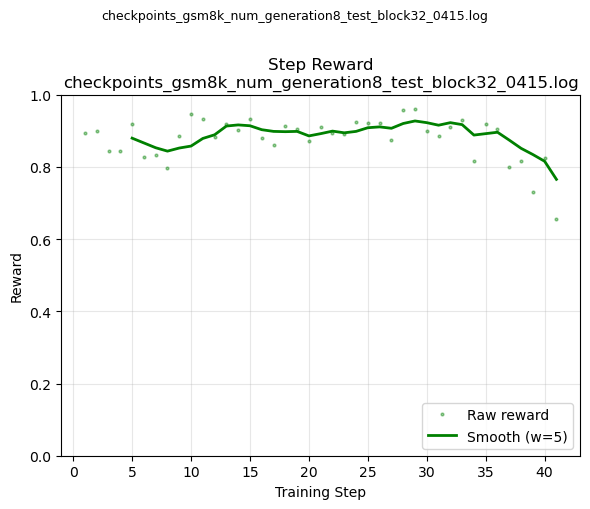

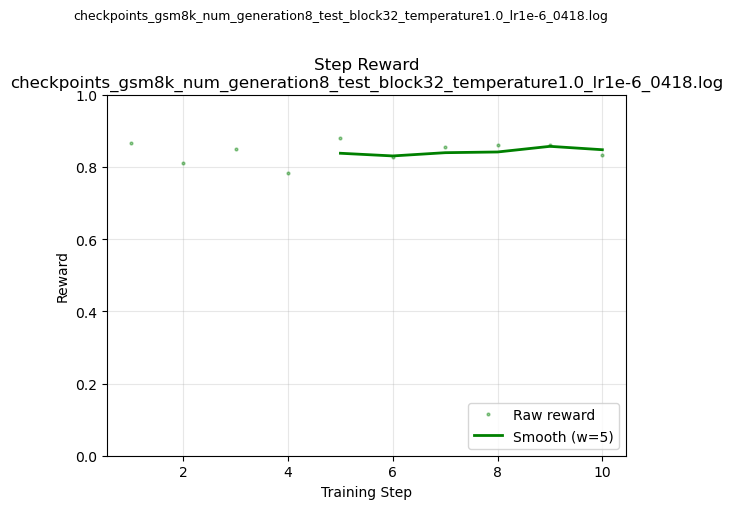

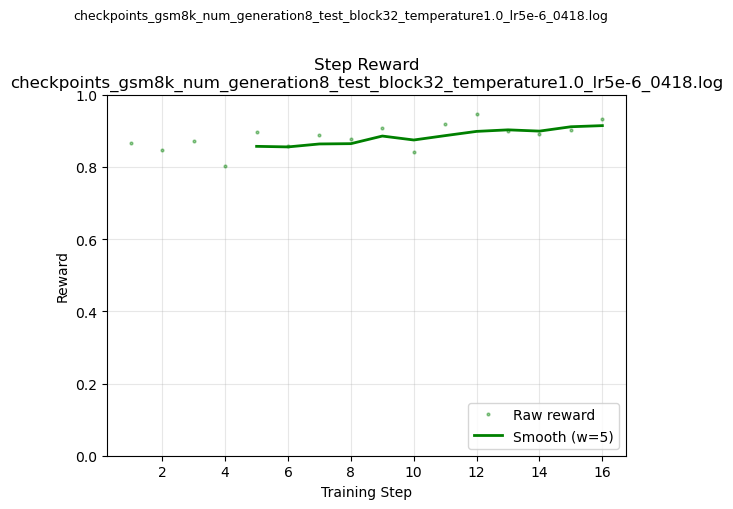

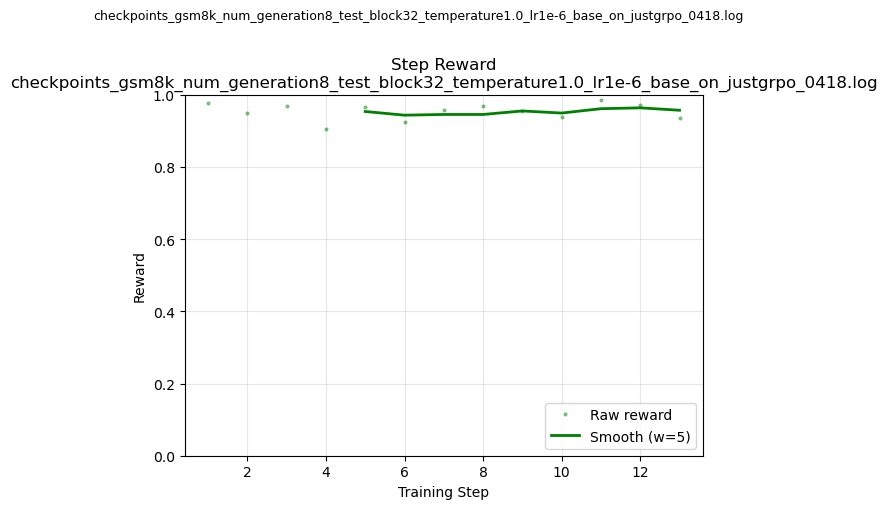

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
matplotlib.rcParams['axes.unicode_minus'] = False


def moving_average(data, window=10):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')


def parse_diversity_line(line):
    try:
        parts = line.strip().split('diversity|')[1].split('|')
        data = {}
        for part in parts:
            if '=' in part:
                k, v = part.split('=', 1)
                data[k.strip()] = v.strip()
        
        answers_str = data.get('extracted_answers', '[]')
        answers = [a.strip().strip("'\"") for a in answers_str.strip('[]').split(',') if a.strip()]
        
        return {
            'distinct_answer_num': int(data.get('distinct_answer_num', 0)),
            'best_is_correct': float(data.get('best_is_correct', 0)),
            'majority_answer': data.get('majority_answer', ''),
            'ground_truth': data.get('ground_truth', ''),
            'extracted_answers': answers,
        }
    except Exception:
        return None


def parse_step_rewards(log_file):
    """从log中提取 [Step X/Y] reward=... grad=... 的真实reward值"""
    rewards = []
    grads = []
    pattern = re.compile(r'\[Step \d+/\d+\] reward=([\d.]+), grad=([\d.]+)')
    with open(log_file, 'r', encoding='utf-8') as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards.append(float(m.group(1)))
                grads.append(float(m.group(2)))
    return rewards, grads


def plot_voting_and_reward_acc_per_file(log_files, save_dir=None, smooth_window=10):
    for log_file in log_files:
        data_list = []
        with open(log_file, 'r', encoding='utf-8') as f:
            for line in f:
                if 'diversity|' in line:
                    data = parse_diversity_line(line)
                    if data:
                        data_list.append(data)

        step_rewards, step_grads = parse_step_rewards(log_file)

        if not data_list and not step_rewards:
            print(f"No data in {log_file}")
            continue

        voting_acc_list = []
        reward_acc_list = []

        for idx, data in enumerate(data_list):
            if data['distinct_answer_num'] <= 1:
                continue

            voting_acc_list.append(data['best_is_correct'])

            if data['majority_answer'] and data['ground_truth']:
                answers = data['extracted_answers']
                majority = data['majority_answer']
                truth = data['ground_truth']
                tp = fp = tn = fn = 0
                for ans in answers:
                    est_reward = 1 if ans == majority else 0
                    true_reward = 1 if ans == truth else 0
                    if est_reward == 1 and true_reward == 1:
                        tp += 1
                    elif est_reward == 1 and true_reward == 0:
                        fp += 1
                    elif est_reward == 0 and true_reward == 0:
                        tn += 1
                    elif est_reward == 0 and true_reward == 1:
                        fn += 1
                total = tp + fp + tn + fn
                reward_acc_list.append((tp + tn) / total if total > 0 else 0)
            else:
                reward_acc_list.append(0)

        has_diversity = len(voting_acc_list) > 0
        has_steps = len(step_rewards) > 0

        n_cols = (2 if has_diversity else 0) + (1 if has_steps else 0)
        if n_cols == 0:
            print(f"No plottable data in {log_file}")
            continue

        fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5))
        if n_cols == 1:
            axes = [axes]

        fname = Path(log_file).name
        ax_idx = 0

        if has_diversity:
            x_raw = np.arange(1, len(voting_acc_list) + 1)
            if len(voting_acc_list) >= smooth_window:
                voting_smooth = moving_average(voting_acc_list, smooth_window)
                reward_smooth = moving_average(reward_acc_list, smooth_window)
                x_smooth = x_raw[smooth_window - 1:]
            else:
                voting_smooth = voting_acc_list
                reward_smooth = reward_acc_list
                x_smooth = x_raw

            def auto_ylim(data, margin=0.05):
                lo, hi = min(data), max(data)
                span = hi - lo if hi > lo else 0.1
                return lo - span * margin, hi + span * margin

            ax1 = axes[ax_idx]
            ax1.plot(x_raw, voting_acc_list, 'b.', alpha=0.3, markersize=3, label='Raw')
            ax1.plot(x_smooth, voting_smooth, 'b-', linewidth=2, label=f'Smooth (w={smooth_window})')
            ax1.set_xlabel('Sample Index (filtered, distinct>1)')
            ax1.set_ylabel('Accuracy')
            ax1.set_title(f'Voting Accuracy\n{fname}')
            ax1.set_ylim(*auto_ylim(voting_acc_list))
            ax1.legend(loc='lower right')
            ax1.grid(True, alpha=0.3)
            ax_idx += 1

            ax2 = axes[ax_idx]
            ax2.plot(x_raw, reward_acc_list, 'r.', alpha=0.3, markersize=3, label='Raw')
            ax2.plot(x_smooth, reward_smooth, 'r-', linewidth=2, label=f'Smooth (w={smooth_window})')
            ax2.set_xlabel('Sample Index (filtered, distinct>1)')
            ax2.set_ylabel('Accuracy')
            ax2.set_title(f'Effective Reward Accuracy\n{fname}')
            ax2.set_ylim(*auto_ylim(reward_acc_list))
            ax2.legend(loc='lower right')
            ax2.grid(True, alpha=0.3)
            ax_idx += 1

        if has_steps:
            ax3 = axes[ax_idx]
            x_steps = np.arange(1, len(step_rewards) + 1)
            ax3.plot(x_steps, step_rewards, 'g.', alpha=0.4, markersize=4, label='Raw reward')
            if len(step_rewards) >= smooth_window:
                reward_smooth_steps = moving_average(step_rewards, smooth_window)
                x_smooth_steps = x_steps[smooth_window - 1:]
                ax3.plot(x_smooth_steps, reward_smooth_steps, 'g-', linewidth=2,
                        label=f'Smooth (w={smooth_window})')
            ax3.set_xlabel('Training Step')
            ax3.set_ylabel('Reward')
            ax3.set_title(f'Step Reward\n{fname}')
            ax3.set_ylim(*auto_ylim(step_rewards))
            ax3.legend(loc='lower right')
            ax3.grid(True, alpha=0.3)

        plt.suptitle(fname, fontsize=9, y=1.01)
        plt.tight_layout()

        # if save_dir:
        #     Path(save_dir).mkdir(parents=True, exist_ok=True)
        #     save_path = Path(save_dir) / (Path(log_file).stem + '_plot.png')
        #     plt.savefig(save_path, dpi=150, bbox_inches='tight')
        #     print(f"Saved: {save_path}")
        # else:
        plt.show()

        plt.close()


log_files = [
    # "logs/checkpoints_math500_num_generation8_block1_t0.6_lr1e-6.log",
    # "logs/checkpoints_math500_num_generation8_block32_t0.6_lr5e-6.log",
    # "logs/checkpoints_math500_num_generation8_block1_t0.6_lr1e-6_only_level1_3.log",
    # "logs/checkpoints_math500_num_generation8_block32_t0.6_lr1e-6_only_level1_3.log",
    'logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log',
    'logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr1e-6_0418.log',
    'logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr5e-6_0418.log',
    'logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr1e-6_base_on_justgrpo_0418.log'
]
plot_voting_and_reward_acc_per_file(log_files, save_dir="plots/", smooth_window=5)

seq_entropy

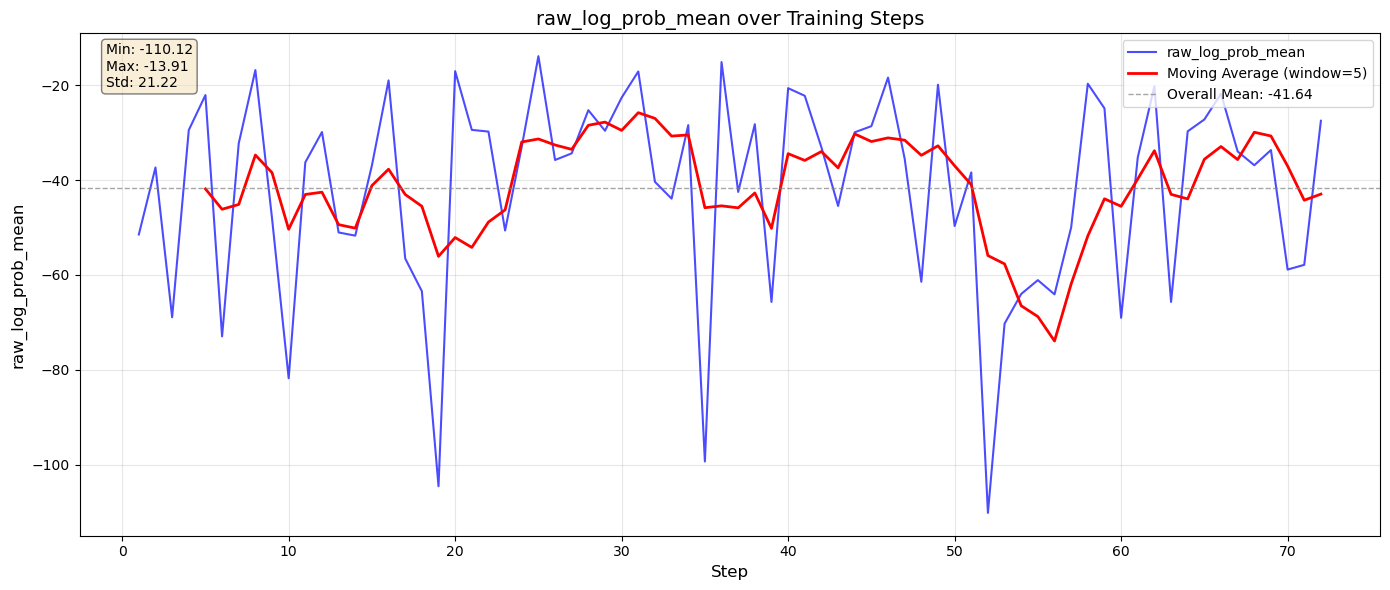

数据点数量: 72
均值: -41.6415
标准差: 21.2216
最小值: -110.1235
最大值: -13.9056


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 原始数据
raw_log_prob_means = [
    -51.4753, -37.3502, -68.9130, -29.4832, -22.1032, -72.9431, -32.2881, -16.8398,
    -48.0447, -81.7603, -36.2659, -29.8900, -51.0446, -51.7163, -36.9224, -19.0141,
    -56.5368, -63.4234, -104.5155, -17.0711, -29.4353, -29.7921, -50.6401, -32.9750,
    -13.9056, -35.7796, -34.3816, -25.2885, -29.6205, -22.6386, -17.1298, -40.3849,
    -43.9217, -28.4330, -99.2966, -15.1439, -42.5067, -28.2449, -65.6822, -20.6500,
    -22.2562, -33.1271, -45.4630, -29.9419, -28.6541, -18.4196, -35.5131, -61.4364,
    -19.9212, -49.6837, -38.3908, -110.1235, -70.2589, -63.9991, -61.0898, -64.0856,
    -49.9872, -19.7147, -24.8949, -69.0204, -35.2438, -20.2310, -65.6793, -29.7370,
    -27.2417, -21.8275, -33.9772, -36.8866, -33.6861, -58.8628, -57.8666, -27.5131
]

steps = list(range(1, len(raw_log_prob_means) + 1))

# 创建图形
fig, ax = plt.subplots(figsize=(14, 6))

# 绘制原始曲线
ax.plot(steps, raw_log_prob_means, 'b-', linewidth=1.5, alpha=0.7, label='raw_log_prob_mean')

# 绘制移动平均线（窗口=5）
window = 5
moving_avg = np.convolve(raw_log_prob_means, np.ones(window)/window, mode='valid')
ax.plot(steps[window-1:], moving_avg, 'r-', linewidth=2, label=f'Moving Average (window={window})')

# 添加水平参考线（均值线）
mean_value = np.mean(raw_log_prob_means)
ax.axhline(y=mean_value, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Overall Mean: {mean_value:.2f}')

# 设置标签和标题
ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('raw_log_prob_mean', fontsize=12)
ax.set_title('raw_log_prob_mean over Training Steps', fontsize=14)

# 添加图例
ax.legend(loc='upper right')

# 添加网格
ax.grid(True, alpha=0.3)

# 显示统计信息
stats_text = f'Min: {min(raw_log_prob_means):.2f}\nMax: {max(raw_log_prob_means):.2f}\nStd: {np.std(raw_log_prob_means):.2f}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('raw_log_prob_curve.png', dpi=150)
plt.show()

# 打印统计信息
print(f"数据点数量: {len(raw_log_prob_means)}")
print(f"均值: {mean_value:.4f}")
print(f"标准差: {np.std(raw_log_prob_means):.4f}")
print(f"最小值: {min(raw_log_prob_means):.4f}")
print(f"最大值: {max(raw_log_prob_means):.4f}")